In [2]:
import csv
from collections import Counter
from statistics import mean, median

##Loding Dataset

In [3]:

with open(r"C:\Users\RITTIKA MAITY\OneDrive\Documents\Employee_data.csv", mode='r', encoding='utf-8-sig') as file:
    reader = csv.reader(file)
    data = list(reader)

# Separate header and records
header = data[0]
rows = data[1:]

print ("Data loded succesfully!")
print("Number of Rows:", len(rows))
print("Number of Columns:", len(header))

Data loded succesfully!
Number of Rows: 74610
Number of Columns: 24


#Display columns

In [4]:
print("Columns:")

for column in header:
    print(column)

Columns:
Employee ID
Age
Gender
Years at Company
Job Role
Monthly Income
Work-Life Balance
Job Satisfaction
Performance Rating
Number of Promotions
Overtime
Distance from Home
Education Level
Marital Status
Number of Dependents
Job Level
Company Size
Company Tenure (In Months)
Remote Work
Leadership Opportunities
Innovation Opportunities
Company Reputation
Employee Recognition
Attrition


Display top 5 rows

In [5]:
for row in rows[:5]:
    print(row)

['8410', '31', 'Male', '19', 'Education', '5390', 'Excellent', 'Medium', 'Average', '2', 'No', '22', 'Associate Degree', 'Married', '0', 'Mid', 'Medium', '89', 'No', 'No', 'No', 'Excellent', 'Medium', 'Stayed']
['64756', '59', 'Female', '4', 'Media', '5534', 'Poor', 'High', 'Low', '3', 'No', '21', 'Masterâ€™s Degree', 'Divorced', '3', 'Mid', 'Medium', '21', 'No', 'No', 'No', 'Fair', 'Low', 'Stayed']
['30257', '24', 'Female', '10', 'Healthcare', '8159', 'Good', 'High', 'Low', '0', 'No', '11', 'Bachelorâ€™s Degree', 'Married', '3', 'Mid', 'Medium', '74', 'No', 'No', 'No', 'Poor', 'Low', 'Stayed']
['65791', '36', 'Female', '7', 'Education', '3989', 'Good', 'High', 'High', '1', 'No', '27', 'High School', 'Single', '2', 'Mid', 'Small', '50', 'Yes', 'No', 'No', 'Good', 'Medium', 'Stayed']
['65026', '56', 'Male', '41', 'Education', '4821', 'Fair', 'Very High', 'Average', '0', 'Yes', '71', 'High School', 'Divorced', '0', 'Senior', 'Medium', '68', 'No', 'No', 'No', 'Fair', 'Medium', 'Stayed']


#finding missing values

In [7]:
missing = {}

for i, column in enumerate(header):
    count = 0

    for row in rows:
        if row[i].strip() == "":
            count += 1

    missing[column] = count

print(missing)

{'Employee ID': 0, 'Age': 0, 'Gender': 0, 'Years at Company': 0, 'Job Role': 0, 'Monthly Income': 0, 'Work-Life Balance': 0, 'Job Satisfaction': 0, 'Performance Rating': 0, 'Number of Promotions': 0, 'Overtime': 0, 'Distance from Home': 1912, 'Education Level': 0, 'Marital Status': 0, 'Number of Dependents': 0, 'Job Level': 0, 'Company Size': 0, 'Company Tenure (In Months)': 2413, 'Remote Work': 0, 'Leadership Opportunities': 0, 'Innovation Opportunities': 0, 'Company Reputation': 0, 'Employee Recognition': 0, 'Attrition': 0}


In [17]:
#check uniqe data
print("Original records:", len(data))

unique_rows = list(set(tuple(row) for row in data))

print("Unique records:", len(unique_rows))

print("Duplicates:", len(data) - len(unique_rows))

Original records: 74611
Unique records: 74499
Duplicates: 112


#Column Data types

In [8]:
print("Column Name\t\tData Type")

for i, column in enumerate(header):
    value = rows[0][i]   # First value in the column

    try:
        int(value)
        dtype = "Integer"
    except ValueError:
        try:
            float(value)
            dtype = "Float"
        except ValueError:
            dtype = "String"

    print(f"{column}\t\t{dtype}")

Column Name		Data Type
Employee ID		Integer
Age		Integer
Gender		String
Years at Company		Integer
Job Role		String
Monthly Income		Integer
Work-Life Balance		String
Job Satisfaction		String
Performance Rating		String
Number of Promotions		Integer
Overtime		String
Distance from Home		Integer
Education Level		String
Marital Status		String
Number of Dependents		Integer
Job Level		String
Company Size		String
Company Tenure (In Months)		Integer
Remote Work		String
Leadership Opportunities		String
Innovation Opportunities		String
Company Reputation		String
Employee Recognition		String
Attrition		String


In [9]:
#finding numarical columns
print("Numerical Columns")

for i in range(len(header)):

    if rows[0][i].isdigit():

        print(header[i])
        

Numerical Columns
Employee ID
Age
Years at Company
Monthly Income
Number of Promotions
Distance from Home
Number of Dependents
Company Tenure (In Months)


#Summery statistics

In [10]:
numeric_columns = [
    "Age",
    "Years at Company",
    "Monthly Income",
    "Number of Promotions",
    "Distance from Home",
    "Number of Dependents",
    "Company Tenure (In Months)"
]

for column in numeric_columns:

    index = header.index(column)

    values = []

    for row in rows:
        if row[index].strip() != "":
            values.append(float(row[index]))

    print("\n", column)
    print("Minimum :", min(values))
    print("Maximum :", max(values))
    print("Mean :", round(mean(values),2))
    print("Median :", median(values))


 Age
Minimum : 18.0
Maximum : 59.0
Mean : 38.53
Median : 39.0

 Years at Company
Minimum : 1.0
Maximum : 51.0
Mean : 15.72
Median : 13.0

 Monthly Income
Minimum : 1226.0
Maximum : 50030.0
Mean : 7344.93
Median : 7348.5

 Number of Promotions
Minimum : 0.0
Maximum : 4.0
Mean : 0.83
Median : 1.0

 Distance from Home
Minimum : 1.0
Maximum : 99.0
Mean : 49.99
Median : 50.0

 Number of Dependents
Minimum : 0.0
Maximum : 15.0
Mean : 1.66
Median : 1.0

 Company Tenure (In Months)
Minimum : 2.0
Maximum : 128.0
Mean : 55.71
Median : 56.0


In [ ]:
#Analyze Categorical Columns(gender)

In [12]:
print("Categorical Columns")

for i in range(len(header)):

    if not rows[0][i].isdigit():

        print(header[i])

Categorical Columns
Gender
Job Role
Work-Life Balance
Job Satisfaction
Performance Rating
Overtime
Education Level
Marital Status
Job Level
Company Size
Remote Work
Leadership Opportunities
Innovation Opportunities
Company Reputation
Employee Recognition
Attrition


In [18]:
categorical_columns = [
    "Gender",
    "Job Role",
    "Work-Life Balance",
    "Job Satisfaction",
    "Performance Rating",
    "Marital Status",
    "Job Level",
    "Company Size",
    "Remote Work",
    "Leadership Opportunities",
    "Innovation Opportunities",
    "Company Reputation",
    "Employee Recognition",
    "Attrition"
]

for column in categorical_columns:

    index = header.index(column)

    values = []

    for row in rows:
        values.append(row[index])

    print("\n", column)
    print(Counter(values))


 Gender
Counter({'Male': 40898, 'Female': 33712})

 Job Role
Counter({'Technology': 19350, 'Healthcare': 17107, 'Education': 15679, 'Media': 12011, 'Finance': 10463})

 Work-Life Balance
Counter({'Good': 28196, 'Fair': 22569, 'Excellent': 13451, 'Poor': 10394})

 Job Satisfaction
Counter({'High': 37306, 'Very High': 15101, 'Medium': 14738, 'Low': 7465})

 Performance Rating
Counter({'Average': 44786, 'High': 14938, 'Below Average': 11150, 'Low': 3736})

 Marital Status
Counter({'Married': 37470, 'Single': 26039, 'Divorced': 11101})

 Job Level
Counter({'Entry': 29820, 'Mid': 29730, 'Senior': 15060})

 Company Size
Counter({'Medium': 37281, 'Small': 22394, 'Large': 14935})

 Remote Work
Counter({'No': 60390, 'Yes': 14220})

 Leadership Opportunities
Counter({'No': 70952, 'Yes': 3658})

 Innovation Opportunities
Counter({'No': 62486, 'Yes': 12124})

 Company Reputation
Counter({'Good': 37241, 'Poor': 15142, 'Fair': 14805, 'Excellent': 7422})

 Employee Recognition
Counter({'Low': 29654,

In [14]:
##Check Attrition Distribution
attrition_index = header.index("Attrition")

attrition = []

for row in rows:
    attrition.append(row[attrition_index])

print(Counter(attrition))

Counter({'Stayed': 39191, 'Left': 35419})


In [15]:
#check highest and lowest incomes
income_index = header.index("Monthly Income")

income = []

for row in rows:
    income.append(float(row[income_index]))

print("Highest Income :", max(income))
print("Lowest Income :", min(income))

Highest Income : 50030.0
Lowest Income : 1226.0


#Visualization

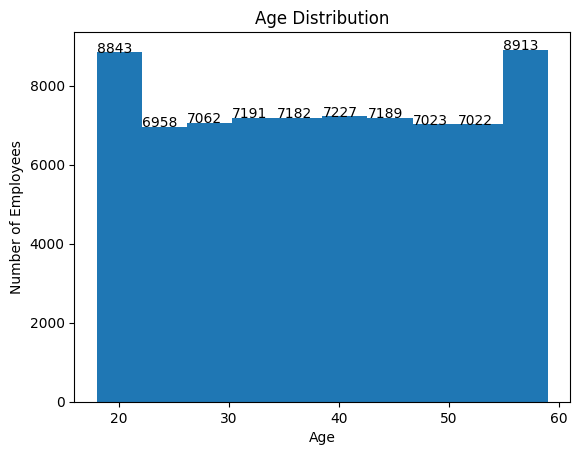

In [6]:
import matplotlib.pyplot as plt

ages = []

age_index = header.index("Age")

for row in rows:
    ages.append(int(row[age_index]))

# Create histogram
counts, bins, patches = plt.hist(ages, bins=10)

# Add labels on each bar
for i in range(len(counts)):
    plt.text(
        bins[i],          # x position
        counts[i],        # y position
        int(counts[i]),   # label
        fontsize=10
    )

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

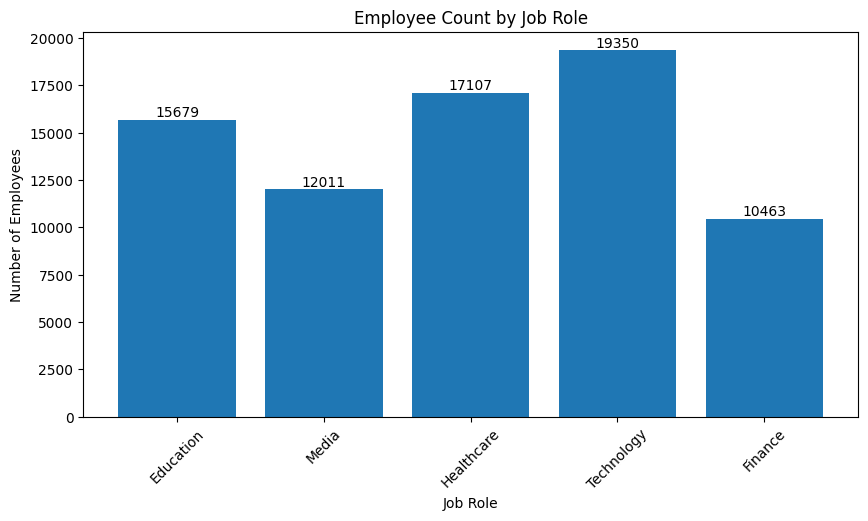

In [19]:
import matplotlib.pyplot as plt

# Find the Job Role column
jobrole_index = header.index("Job Role")

# Count employees in each job role
jobrole_count = {}

for row in rows:
    jobrole = row[jobrole_index]

    if jobrole in jobrole_count:
        jobrole_count[jobrole] += 1
    else:
        jobrole_count[jobrole] = 1

# Create bar chart
plt.figure(figsize=(10,5))
plt.bar(jobrole_count.keys(), jobrole_count.values())

#add labels
for bar in bars:
    height=bar.get_height()
    plt.text(
        bar.get_x()+ bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.title("Employee Count by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

plt.show()

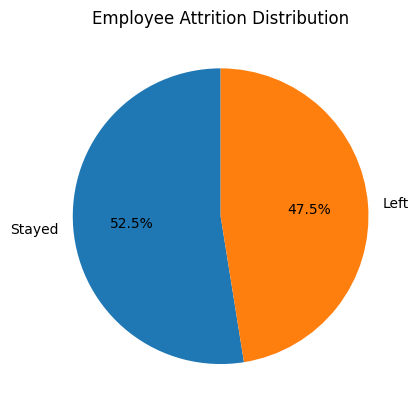

In [24]:
import matplotlib.pyplot as plt
from collections import Counter

# Find the Attrition column index
attrition_index = header.index("Attrition")

# Store attrition values
attrition = []

for row in rows:
    attrition.append(row[attrition_index])

# Count each category
count = Counter(attrition)

# Create pie chart
plt.pie(
    count.values(),
    labels=count.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Employee Attrition Distribution")
plt.show()

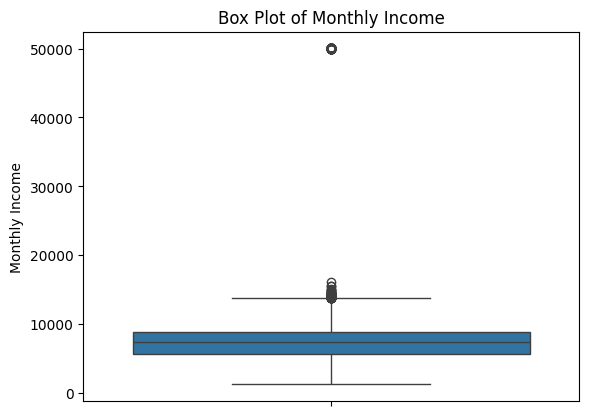

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Find Monthly Income column
income_index = header.index("Monthly Income")

# Store income values
income = []

for row in rows:
    income.append(float(row[income_index]))

# Create box plot
sns.boxplot(y=income)

plt.title("Box Plot of Monthly Income")
plt.ylabel("Monthly Income")
plt.show()

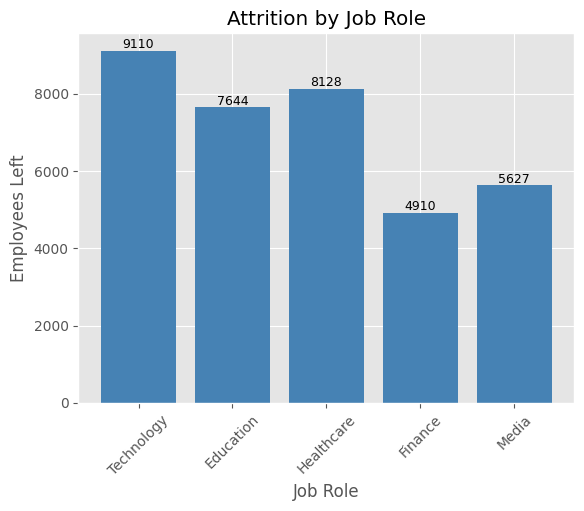

In [31]:
## Attrition by job role

import matplotlib.pyplot as plt

job_index = header.index("Job Role")
attrition_index = header.index("Attrition")

count = {}

for row in rows:

    if row[attrition_index] == "Left":

        job = row[job_index]

        if job in count:
            count[job] += 1
        else:
            count[job] = 1

plt.bar(count.keys(), count.values())

bars = plt.bar(count.keys(), count.values(), color="steelblue")

# Data Labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             str(int(bar.get_height())),
             ha='center',
             va='bottom',
             fontsize=9)

plt.title("Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Employees Left")

plt.xticks(rotation=45)

plt.show()

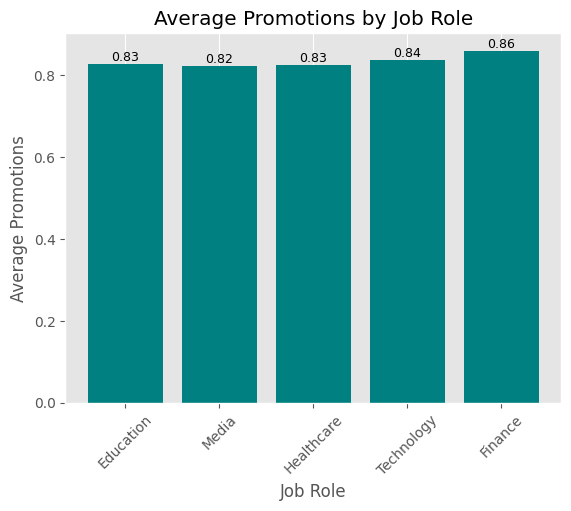

In [34]:
### avg promotion by job role
import matplotlib.pyplot as plt

job_index = header.index("Job Role")
promotion_index = header.index("Number of Promotions")

total = {}
count = {}

for row in rows:
    job = row[job_index]

    try:
        promotion = int(row[promotion_index])
    except:
        continue

    if job in total:
        total[job] += promotion
        count[job] += 1
    else:
        total[job] = promotion
        count[job] = 1

jobs = list(total.keys())
avg = [total[j] / count[j] for j in jobs]

bars = plt.bar(jobs, avg, color="teal")

# Data labels
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f"{h:.2f}", ha="center", va="bottom", fontsize=9)

plt.title("Average Promotions by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Average Promotions")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

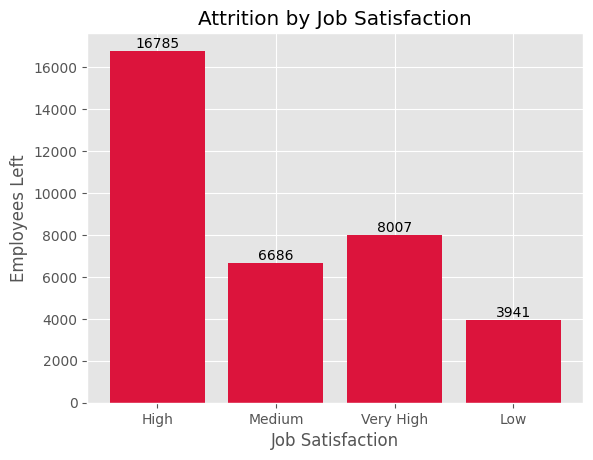

In [9]:
## attrition by job satisfaction
import matplotlib.pyplot as plt

plt.style.use("ggplot")

job_index = header.index("Job Satisfaction")
attrition_index = header.index("Attrition")

count = {}

for row in rows:

    if row[attrition_index] == "Left": 

        job = row[job_index]

        if job in count:
            count[job] += 1
        else:
            count[job] = 1

bars = plt.bar(
    count.keys(),
    count.values(),
    color="crimson" )
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=10 )
plt.title("Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Employees Left")

plt.show()

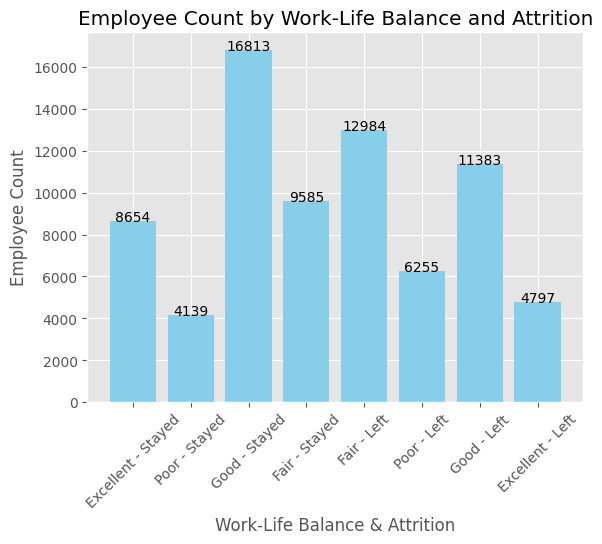

In [10]:
## count of emp_id by work life balance & attrition

import matplotlib.pyplot as plt

plt.style.use("ggplot")

wlb_index = header.index("Work-Life Balance")
attrition_index = header.index("Attrition")

count = {}

for row in rows:
    key = row[wlb_index] + " - " + row[attrition_index]

    if key in count:
        count[key] += 1
    else:
        count[key] = 1

bars = plt.bar(count.keys(), count.values(), color="skyblue")

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             str(int(bar.get_height())),
             ha="center")

plt.title("Employee Count by Work-Life Balance and Attrition")
plt.xlabel("Work-Life Balance & Attrition")
plt.ylabel("Employee Count")

plt.xticks(rotation=45)

plt.show()

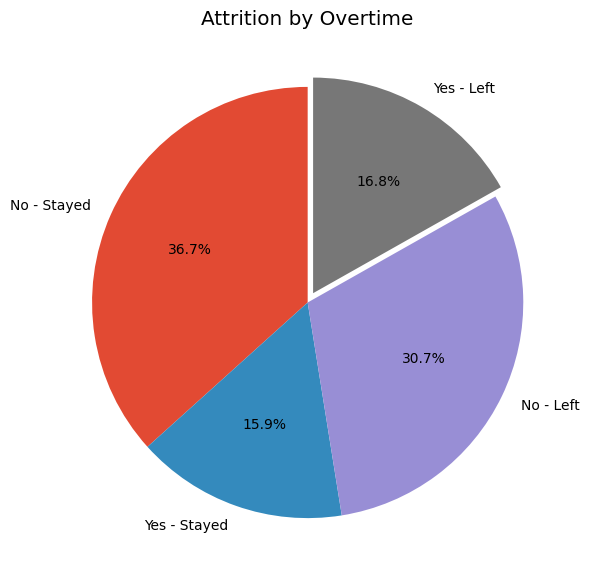

In [15]:
## attrition by overtime

import matplotlib.pyplot as plt

plt.style.use("ggplot")

overtime_index = header.index("Overtime")
attrition_index = header.index("Attrition")

count = {}

for row in rows:
    key = row[overtime_index] + " - " + row[attrition_index]

    if key in count:
        count[key] += 1
    else:
        count[key] = 1

labels = list(count.keys())
sizes = list(count.values())

explode = [0] * len(labels)

for i in range(len(labels)):
    if labels[i] == "Yes - Left": 
        explode[i] = 0.05

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    explode=explode,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Attrition by Overtime")

plt.show()

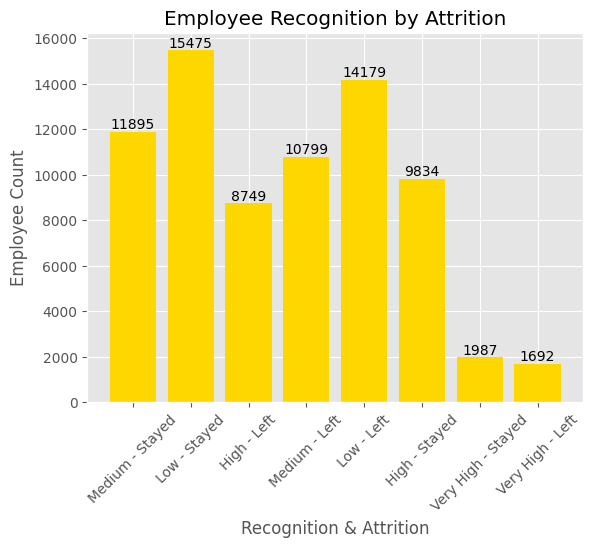

In [19]:
##emp recognition by attrition

import matplotlib.pyplot as plt

plt.style.use("ggplot")

recognition_index = header.index("Employee Recognition")
attrition_index = header.index("Attrition")

count = {}

for row in rows:
    key = row[recognition_index] + " - " + row[attrition_index]

    if key in count:
        count[key] += 1
    else:
        count[key] = 1

bars = plt.bar(count.keys(), count.values(), color="gold")

# Add data labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.title("Employee Recognition by Attrition")
plt.xlabel("Recognition & Attrition")
plt.ylabel("Employee Count")
plt.xticks(rotation=45)

plt.show()

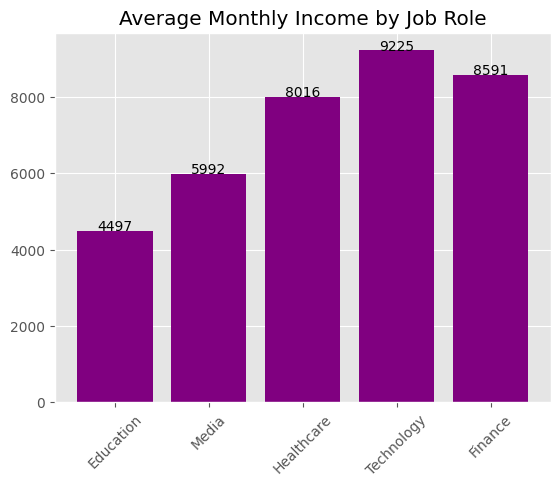

In [30]:
## avg of monthly income by job role

import matplotlib.pyplot as plt

job = header.index("Job Role")
income = header.index("Monthly Income")

total = {}
count = {}

for row in rows:
    if row[income] == "":
        continue
    total[row[job]] = total.get(row[job], 0) + float(row[income])
    count[row[job]] = count.get(row[job], 0) + 1

x = list(total.keys())
y = [total[i] / count[i] for i in x]

bars = plt.bar(x, y, color="purple")

for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
             f"{bar.get_height():.0f}", ha="center")

plt.title("Average Monthly Income by Job Role")
plt.xticks(rotation=45)
plt.show()

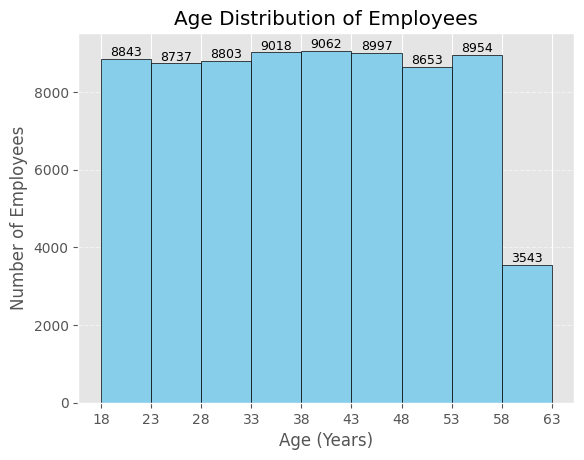

In [35]:
## number of employees by age distribution

import matplotlib.pyplot as plt

ages = []

age_index = header.index("Age")

for row in rows:
    try:
        ages.append(int(row[age_index]))
    except:
        pass

# Correct 5-year bins
bin_edges = [18, 23, 28, 33, 38, 43, 48, 53, 58, 63]

counts, bins, patches = plt.hist(
    ages,
    bins=bin_edges,
    color="skyblue",
    edgecolor="black"
)

# Data labels
for i in range(len(counts)):
    plt.text(
        (bins[i] + bins[i+1]) / 2,
        counts[i],
        str(int(counts[i])),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Age Distribution of Employees")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Employees")
plt.xticks(bin_edges)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()